# Benchmark
Here I will benchmark the two models, namely the linear Neural Network (NN) model and the MultiLayer Perception (MLP) models.

In [52]:
from importlib import reload
import MLPModel, LinearModel 
import Model_Training
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)
import torch

# Set randomization seed for controlled performance
seed = 22
torch.manual_seed(seed)

A typical training will look like:

In [53]:


ticker = "BTC-USD"
start = '2023-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.75
no_epoches = 100_000
lr = 0.001
tx_fees_bpts = 10

max_lags = 4

modelMLP = MLPModel.MLP # multiplayer perception 

Model = Model_Training.model_training(model = modelMLP(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5,
                              trade_signal = "sign",
                              threshold=0.001,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True)

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

ModelLin = Model_Training.model_training(model = modelLinear(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5 ,
                              trade_signal = "sign",
                              threshold=0.001,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Training model...
Epoch 0/100000, Loss = 0.998051643
Epoch 500/100000, Loss = 0.957279623
Relative Tolance Reached at Epoch 556

 Training Finished! 
 Loss = 0.955616415
Test Loss = 0.609268248

Test Loss = 0.000401112 
Train Loss = 0.000629107

Training model...
Epoch 0/100000, Loss = 1.355095625
Epoch 500/100000, Loss = 1.016274571
Relative Tolance Reached at Epoch 880

 Training Finished! 
 Loss = 0.996053934
Test Loss = 0.601177633

Test Loss = 0.000395786 
Train Loss = 0.000655746



Test Loss = 0.000401112 
Train Loss = 0.000629107

Test Loss = 0.000395786 
Train Loss = 0.000655746


Text(0.5, 1.0, 'Linear Model')

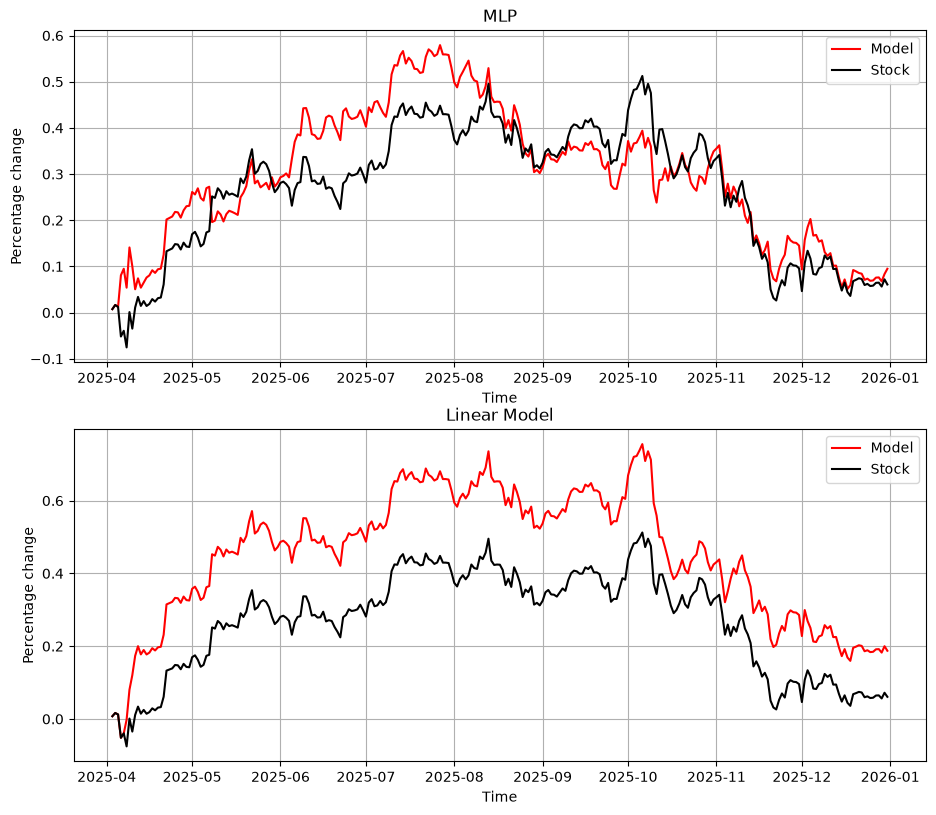

In [54]:

fx_fees_bpts = 0

import matplotlib.pyplot as plt
fig, (ax1,ax2) = plt.subplots(2,1, figsize = (11,9.5))

Model.get_trade_results("sign",0, fx_fees_bpts)
ModelLin.get_trade_results("sign",0, fx_fees_bpts)


Model.model_against_stock(ax1)
ModelLin.model_against_stock(ax2)

ax1.set_title("MLP")
ax2.set_title("Linear Model")

# Model.date_test

## Performace with different lookback

In [55]:
import pandas as pd 

lookbacks = range(1,64) # From one day to roughly above two months

df_LB = pd.DataFrame({}) # Generate the dataframe which we will append to in the end


ticker = "AAPL"
start = '2024-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval

train_ratio = 0.60
no_epoches = 100_000
lr = 0.0001
tx_cost = 10
atol = 1e-8

performance_results = [] # List which we will later fill with dataframes

for lb in lookbacks:
    # Train both the MLP and Linear models at lookback lb
    
    modelMLP = MLPModel.MLP # multiplayer perception 
    Model = Model_Training.model_training(model = modelMLP(lb),
                                tick = ticker,
                                start = start,
                                end = end ,
                                interval = interval,
                                train_ratio = train_ratio,
                                max_lags = lb,
                                no_epochs=no_epoches,
                                lr = lr,
                                rtol = 1e-5,
                                atol = atol,
                                trade_signal = "sign",
                                transaction_cost_bpts=tx_cost,
                                threshold=0.001)
    
    Model.get_model_performance()
    mlp_df = Model.performance_df 
    mlp_df.insert(0, "Model", "MLP")
    mlp_df.insert(1, "Lag", int(lb))
    
    performance_results.append(mlp_df)

    modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

    ModelLin = Model_Training.model_training(model = modelLinear(lb),
                                tick = ticker,
                                start = start,
                                end = end ,
                                interval = interval,
                                train_ratio = train_ratio,
                                max_lags = lb,
                                no_epochs=no_epoches,
                                lr = lr,
                                rtol = 1e-5 ,
                                atol = atol,
                                trade_signal = "sign",
                                transaction_cost_bpts=tx_cost,
                                threshold=0.001)
    
    ModelLin.get_model_performance(

    )
    linear_df = ModelLin.performance_df 
    
    linear_df.insert(0, "Model", "linear")
    linear_df.insert(1, "Lag", int(lb))
    
    performance_results.append(linear_df)
    
df_LB = pd.concat(
    performance_results,
    ignore_index=True,
)

        
    



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [56]:
df_LB

,Model,Lag,max_drawdown_log,drawdown_percentage,win_rate,average_win,average_loss,expected_value_per_trade,total_log_return,compounded_return,equity_multiplier,equity_trough,equity_peak,return_std,annualized_sharpe_stocks,annualized_sharpe_crypto
0,MLP,1,-0.261222,-0.229890,0.545000,0.012512,-0.012331,0.001209,0.241724,0.273443,1.273443,-0.217043,0.293093,0.020596,0.931547,1.121117
1,linear,1,-0.352784,-0.297271,0.520000,0.011253,-0.013704,-0.000726,-0.145264,-0.135206,0.864794,-0.352784,-0.007141,0.020663,-0.558010,-0.671565
2,MLP,2,-0.261222,-0.229890,0.545000,0.012512,-0.012331,0.001209,0.241724,0.273443,1.273443,-0.217043,0.293093,0.020596,0.931547,1.121117
3,linear,2,-0.223464,-0.200257,0.515000,0.013004,-0.011861,0.000945,0.188916,0.207939,1.207939,-0.179465,0.240284,0.020482,0.732108,0.881092
4,MLP,3,-0.144326,-0.134395,0.575000,0.011760,-0.012959,0.001254,0.250884,0.285161,1.285161,-0.120254,0.284654,0.020573,0.967914,1.164884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,linear,61,-0.616517,-0.460178,0.437500,0.007781,-0.011951,-0.003318,-0.584019,-0.442348,0.557652,-0.584020,0.032497,0.014276,-3.689917,-4.440816
122,MLP,62,-0.166426,-0.153314,0.511364,0.009260,-0.010429,-0.000361,-0.063496,-0.061522,0.938478,-0.063496,0.102930,0.014437,-0.396685,-0.477411
123,linear,62,-0.629727,-0.467263,0.431818,0.008069,-0.011750,-0.003192,-0.561803,-0.429820,0.570180,-0.564279,0.065447,0.014309,-3.541270,-4.261919
124,MLP,63,-0.242466,-0.215310,0.482955,0.009426,-0.010693,-0.000976,-0.171799,-0.157851,0.842149,-0.171799,0.070667,0.014584,-1.062473,-1.278687


In [57]:
df_MLP = df_LB[df_LB["Model"] == "MLP"]
df_Lin = df_LB[df_LB["Model"] == "linear"]

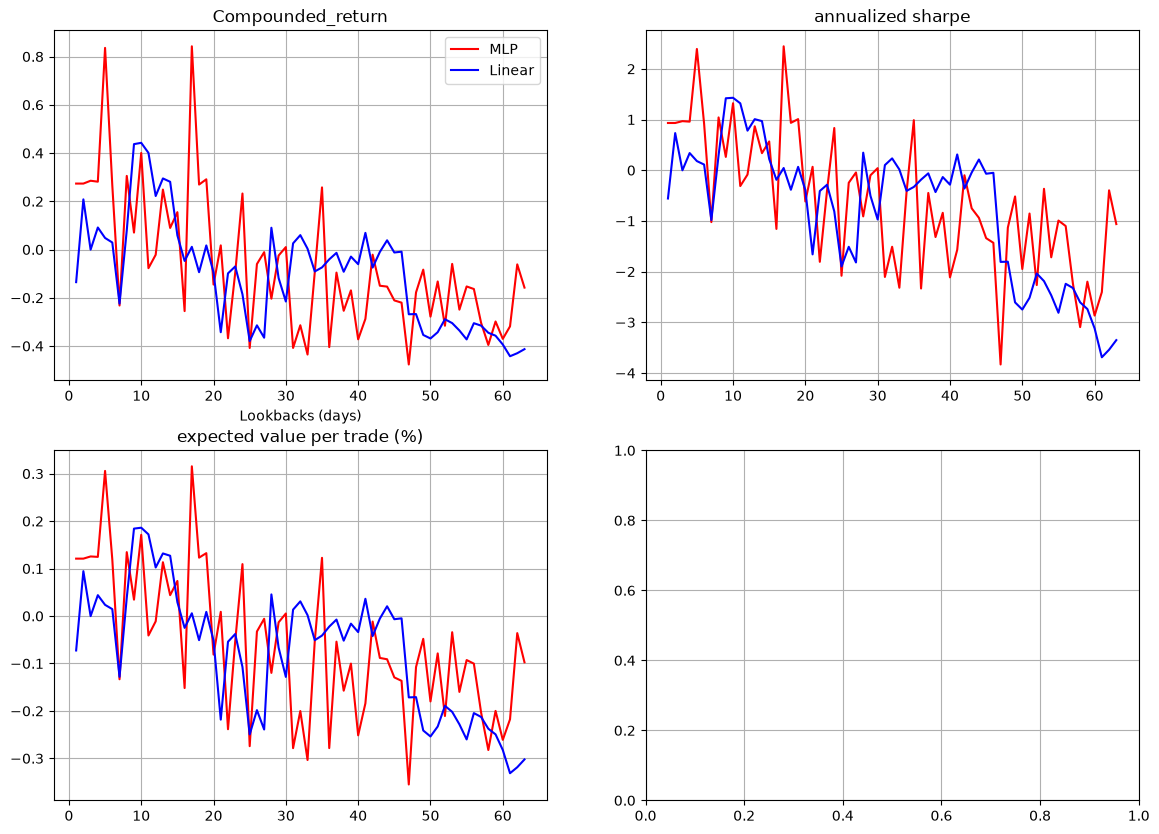

In [58]:
from matplotlib import pyplot as plt 

def draw_benchmarks(df_LB,lookbacks):
    df_MLP = df_LB[df_LB["Model"] == "MLP"]
    df_Lin = df_LB[df_LB["Model"] == "linear"]
    
    fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize = (14,10))
    
    axes = [ax1, ax2 ,ax3, ax4]
    ax1.plot(lookbacks, df_MLP["compounded_return"], label='MLP',c='r')
    ax1.plot(lookbacks, df_Lin["compounded_return"], label='Linear',c='blue')
    ax1.set_xlabel("Lookbacks (days)")
    ax1.set_title("Compounded_return")
    
    ax2.plot(lookbacks, df_MLP["annualized_sharpe_stocks"], label='MLP',c='r')
    ax2.plot(lookbacks, df_Lin["annualized_sharpe_stocks"], label='Linear',c='blue')
    ax2.set_title("annualized sharpe")
    
    ax3.plot(lookbacks, np.expm1(df_MLP["expected_value_per_trade"]) * 100, label="MLP", c='r')
    ax3.plot(lookbacks, np.expm1(df_Lin["expected_value_per_trade"]) * 100, label="Linear", c='blue')
    ax3.set_title("expected value per trade (%)")
    
    ax1.legend()
    for ax in axes:
        ax.grid(True)

    



# plt.plot(lookbacks,df_MLP["compounded_return"])
# plt.plot(lookbacks,df_Lin["compounded_return"])

draw_benchmarks(df_LB,lookbacks)
# df_MLP["compounded_return"].shape
# print(df_MLP.shape)